# DermMel 敵対的防御性能比較: DDPM vs JPEG

このノートブックでは、DermMelデータセットにおける敵対的攻撃に対する防御手法（DDPMとJPEG圧縮）の性能を比較します。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# スタイル設定
plt.rcParams['font.size'] = 12
plt.rcParams['figure.figsize'] = (14, 10)
sns.set_palette("husl")

In [2]:
# 実験データ
attacks = ['FGSM', 'PGD-10', 'AutoAttack']

# 精度データ
clean_acc = [1.0000, 1.0000, 1.0000]
adversarial_acc = [0.4342, 0.0000, 0.0000]
ddpm_acc = [0.5347, 0.6491, 0.6197]
jpeg_acc = [0.4953, 0.4956, 0.4956]

# 改善率データ
ddpm_improvement = [0.1005, 0.6491, 0.6197]
jpeg_improvement = [0.0612, 0.4956, 0.4956]

# Perturbation データ (L2 norm)
ddpm_l2 = [9.21, 8.96, 9.21]
jpeg_l2 = [11.46, 10.64, 10.97]

# Perturbation データ (Linf norm)
ddpm_linf = [0.207, 0.203, 0.207]
jpeg_linf = [0.230, 0.220, 0.223]

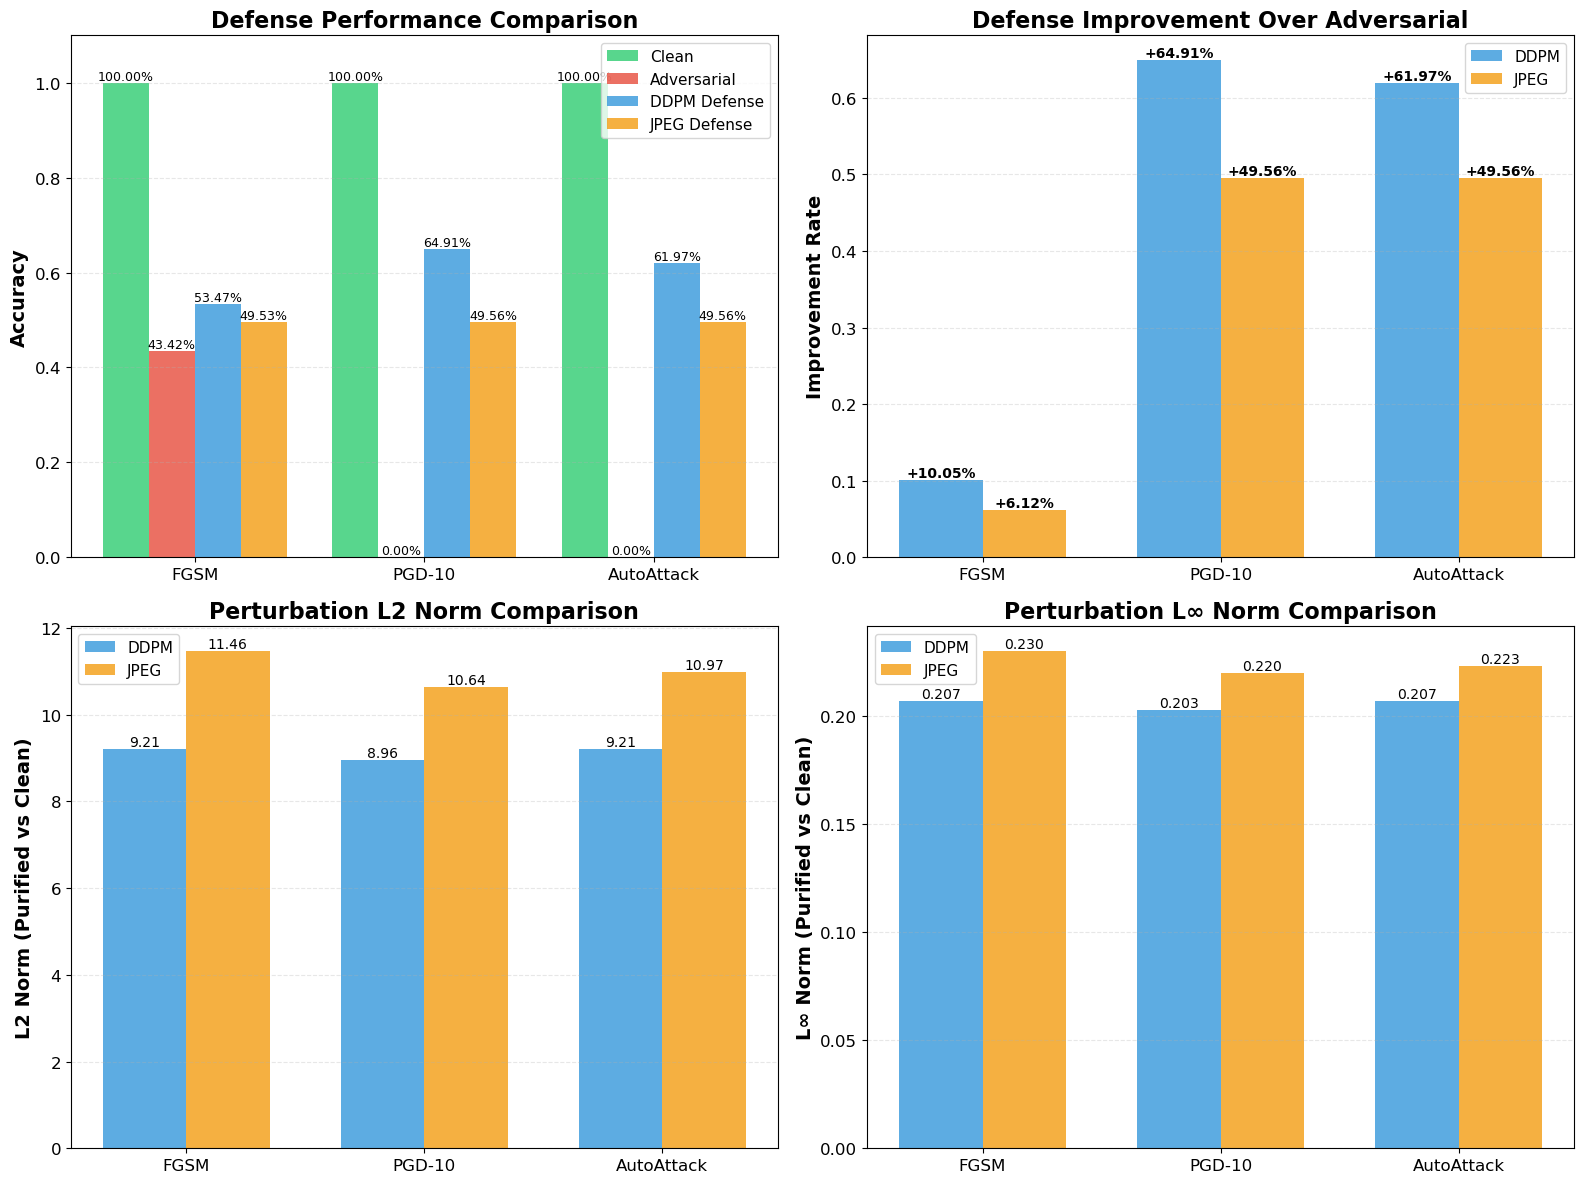

In [3]:
# 図1: 精度比較（棒グラフ）
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1-1: 精度比較
x = np.arange(len(attacks))
width = 0.2

ax = axes[0, 0]
bars1 = ax.bar(x - width*1.5, clean_acc, width, label='Clean', color='#2ecc71', alpha=0.8)
bars2 = ax.bar(x - width*0.5, adversarial_acc, width, label='Adversarial', color='#e74c3c', alpha=0.8)
bars3 = ax.bar(x + width*0.5, ddpm_acc, width, label='DDPM Defense', color='#3498db', alpha=0.8)
bars4 = ax.bar(x + width*1.5, jpeg_acc, width, label='JPEG Defense', color='#f39c12', alpha=0.8)

ax.set_ylabel('Accuracy', fontsize=14, fontweight='bold')
ax.set_title('Defense Performance Comparison', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(attacks, fontsize=12)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(0, 1.1)

# 値をバーの上に表示
for bars in [bars1, bars2, bars3, bars4]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2%}',
                ha='center', va='bottom', fontsize=9)

# 1-2: 改善率比較
ax = axes[0, 1]
x = np.arange(len(attacks))
width = 0.35

bars1 = ax.bar(x - width/2, ddpm_improvement, width, label='DDPM', color='#3498db', alpha=0.8)
bars2 = ax.bar(x + width/2, jpeg_improvement, width, label='JPEG', color='#f39c12', alpha=0.8)

ax.set_ylabel('Improvement Rate', fontsize=14, fontweight='bold')
ax.set_title('Defense Improvement Over Adversarial', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(attacks, fontsize=12)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# 値をバーの上に表示
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'+{height:.2%}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

# 2-1: L2 Perturbation比較
ax = axes[1, 0]
x = np.arange(len(attacks))
width = 0.35

bars1 = ax.bar(x - width/2, ddpm_l2, width, label='DDPM', color='#3498db', alpha=0.8)
bars2 = ax.bar(x + width/2, jpeg_l2, width, label='JPEG', color='#f39c12', alpha=0.8)

ax.set_ylabel('L2 Norm (Purified vs Clean)', fontsize=14, fontweight='bold')
ax.set_title('Perturbation L2 Norm Comparison', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(attacks, fontsize=12)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# 値をバーの上に表示
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}',
                ha='center', va='bottom', fontsize=10)

# 2-2: L∞ Perturbation比較
ax = axes[1, 1]
x = np.arange(len(attacks))
width = 0.35

bars1 = ax.bar(x - width/2, ddpm_linf, width, label='DDPM', color='#3498db', alpha=0.8)
bars2 = ax.bar(x + width/2, jpeg_linf, width, label='JPEG', color='#f39c12', alpha=0.8)

ax.set_ylabel('L∞ Norm (Purified vs Clean)', fontsize=14, fontweight='bold')
ax.set_title('Perturbation L∞ Norm Comparison', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(attacks, fontsize=12)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# 値をバーの上に表示
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('/mnt/data1/gotou/projects/dermmel/defense_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

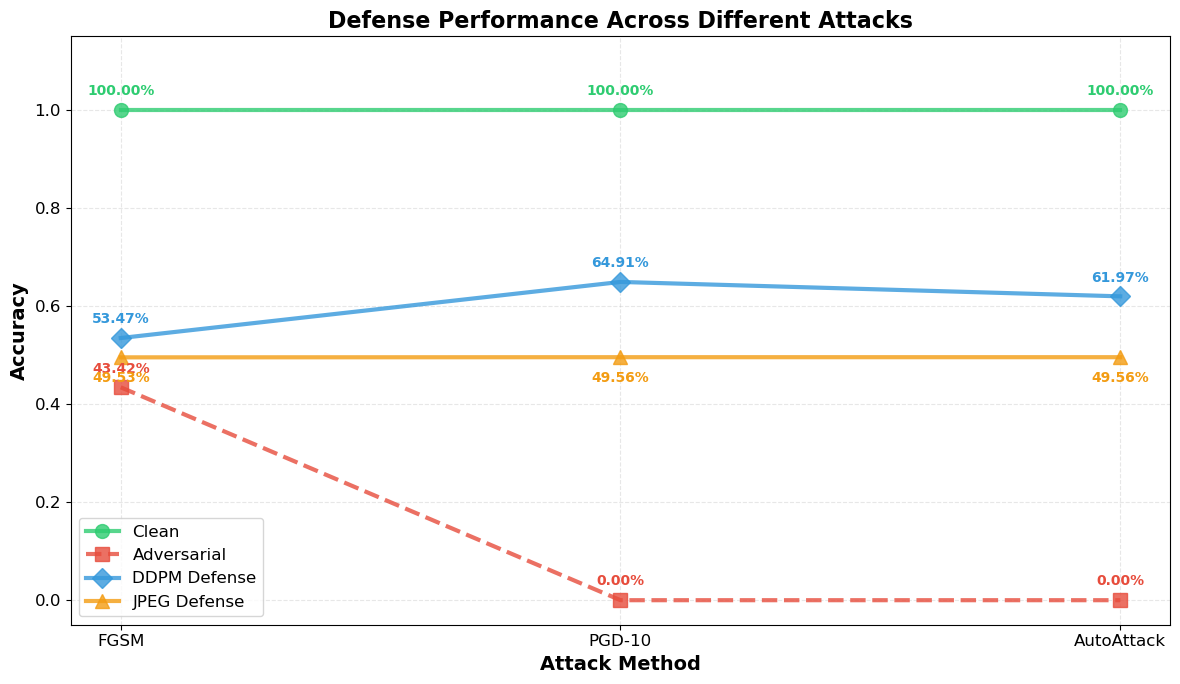

In [4]:
# 図2: 折れ線グラフで精度推移を比較
fig, ax = plt.subplots(1, 1, figsize=(12, 7))

x = np.arange(len(attacks))

# プロット
ax.plot(x, clean_acc, marker='o', linewidth=3, markersize=10, 
        label='Clean', color='#2ecc71', linestyle='-', alpha=0.8)
ax.plot(x, adversarial_acc, marker='s', linewidth=3, markersize=10, 
        label='Adversarial', color='#e74c3c', linestyle='--', alpha=0.8)
ax.plot(x, ddpm_acc, marker='D', linewidth=3, markersize=10, 
        label='DDPM Defense', color='#3498db', linestyle='-', alpha=0.8)
ax.plot(x, jpeg_acc, marker='^', linewidth=3, markersize=10, 
        label='JPEG Defense', color='#f39c12', linestyle='-', alpha=0.8)

# ラベルと値の表示
for i, attack in enumerate(attacks):
    ax.text(i, clean_acc[i] + 0.03, f'{clean_acc[i]:.2%}', 
            ha='center', fontsize=10, color='#2ecc71', fontweight='bold')
    ax.text(i, adversarial_acc[i] + 0.03, f'{adversarial_acc[i]:.2%}', 
            ha='center', fontsize=10, color='#e74c3c', fontweight='bold')
    ax.text(i, ddpm_acc[i] + 0.03, f'{ddpm_acc[i]:.2%}', 
            ha='center', fontsize=10, color='#3498db', fontweight='bold')
    ax.text(i, jpeg_acc[i] - 0.05, f'{jpeg_acc[i]:.2%}', 
            ha='center', fontsize=10, color='#f39c12', fontweight='bold')

ax.set_ylabel('Accuracy', fontsize=14, fontweight='bold')
ax.set_xlabel('Attack Method', fontsize=14, fontweight='bold')
ax.set_title('Defense Performance Across Different Attacks', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(attacks, fontsize=12)
ax.legend(fontsize=12, loc='best')
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_ylim(-0.05, 1.15)

plt.tight_layout()
plt.savefig('/mnt/data1/gotou/projects/dermmel/defense_accuracy_trend.png', dpi=300, bbox_inches='tight')
plt.show()

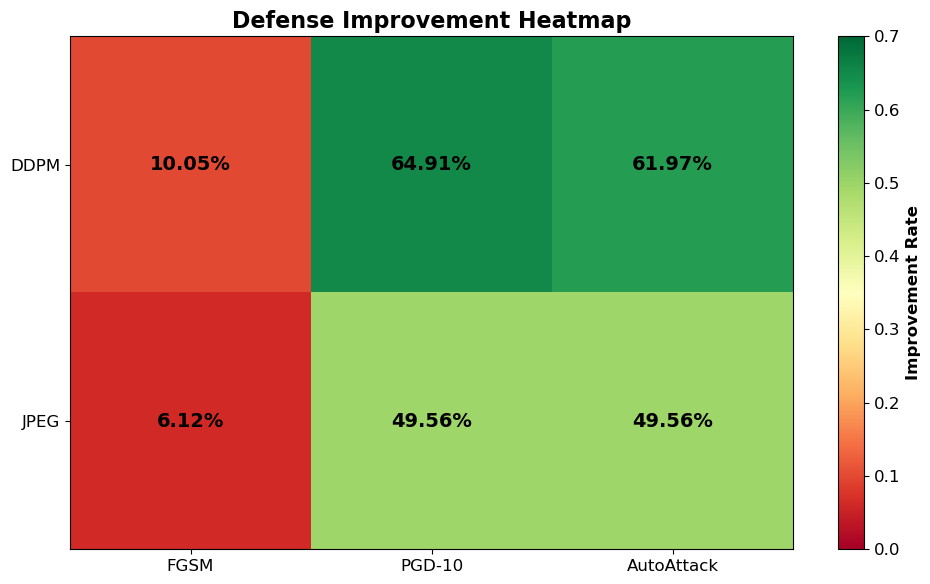

In [5]:
# 図3: ヒートマップで改善率を可視化
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# データを2D配列に整形
data = np.array([ddpm_improvement, jpeg_improvement])

# ヒートマップ作成
im = ax.imshow(data, cmap='RdYlGn', aspect='auto', vmin=0, vmax=0.7)

# カラーバー
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Improvement Rate', fontsize=12, fontweight='bold')

# 軸設定
ax.set_xticks(np.arange(len(attacks)))
ax.set_yticks(np.arange(2))
ax.set_xticklabels(attacks, fontsize=12)
ax.set_yticklabels(['DDPM', 'JPEG'], fontsize=12)

# 値を表示
for i in range(2):
    for j in range(len(attacks)):
        text = ax.text(j, i, f'{data[i, j]:.2%}',
                      ha="center", va="center", color="black", 
                      fontsize=14, fontweight='bold')

ax.set_title('Defense Improvement Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('/mnt/data1/gotou/projects/dermmel/defense_improvement_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

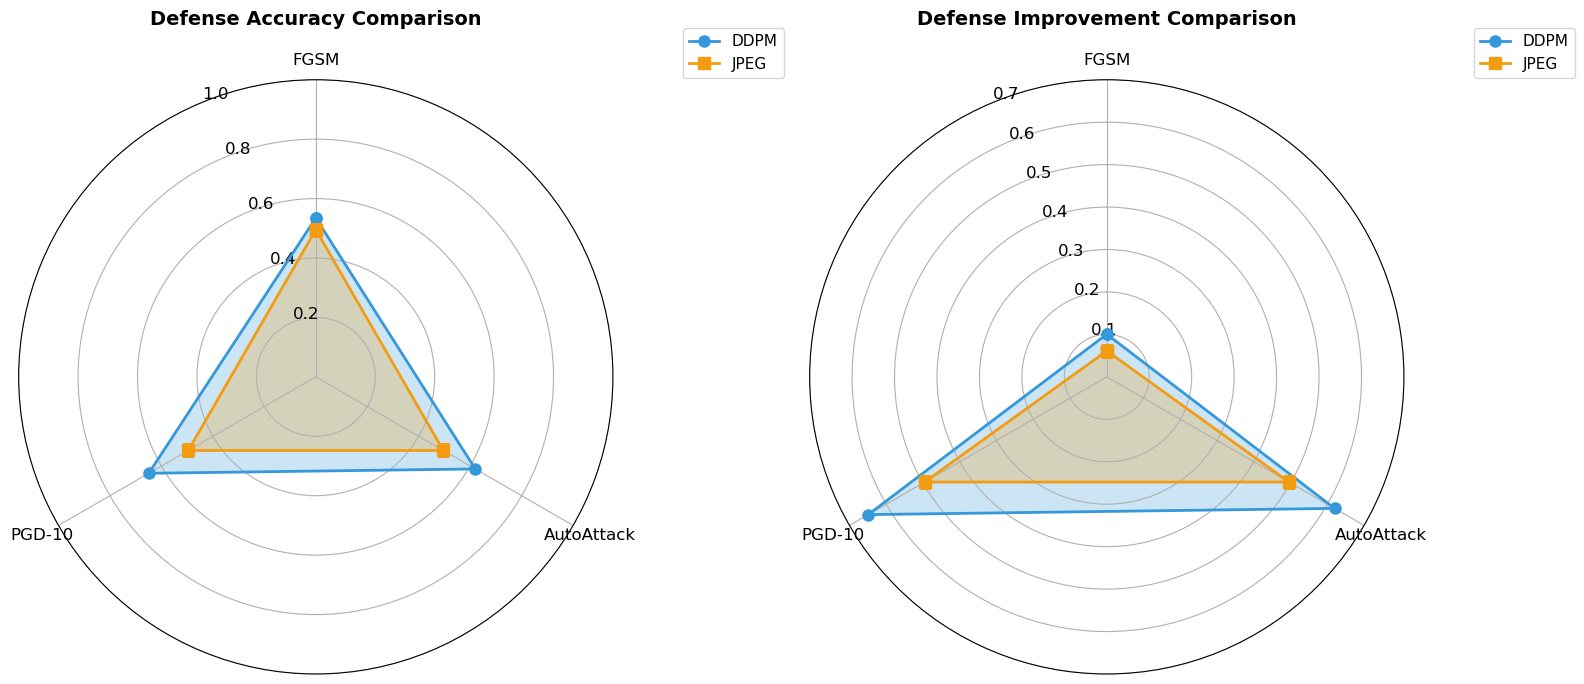

In [6]:
# 図4: レーダーチャートで総合比較
from matplotlib.patches import Circle, RegularPolygon
from matplotlib.path import Path
from matplotlib.projections.polar import PolarAxes
from matplotlib.projections import register_projection
from matplotlib.spines import Spine
from matplotlib.transforms import Affine2D

def radar_factory(num_vars, frame='circle'):
    theta = np.linspace(0, 2*np.pi, num_vars, endpoint=False)
    
    class RadarAxes(PolarAxes):
        name = 'radar'
        
        def __init__(self, *args, **kwargs):
            super().__init__(*args, **kwargs)
            self.set_theta_zero_location('N')
            
        def fill(self, *args, closed=True, **kwargs):
            return super().fill(closed=closed, *args, **kwargs)
            
        def plot(self, *args, **kwargs):
            lines = super().plot(*args, **kwargs)
            for line in lines:
                self._close_line(line)
                
        def _close_line(self, line):
            x, y = line.get_data()
            if x[0] != x[-1]:
                x = np.concatenate((x, [x[0]]))
                y = np.concatenate((y, [y[0]]))
                line.set_data(x, y)
                
        def set_varlabels(self, labels):
            self.set_thetagrids(np.degrees(theta), labels)
            
        def _gen_axes_patch(self):
            return Circle((0.5, 0.5), 0.5)
            
        def _gen_axes_spines(self):
            spine = Spine(axes=self,
                         spine_type='circle',
                         path=Path.unit_circle())
            spine.set_transform(Affine2D().scale(.5).translate(.5, .5)
                              + self.transAxes)
            return {'polar': spine}
            
    register_projection(RadarAxes)
    return theta

# 3つの攻撃に対する性能
N = len(attacks)
theta = radar_factory(N, frame='polygon')

fig, axes = plt.subplots(1, 2, figsize=(16, 7), 
                         subplot_kw=dict(projection='radar'))

# データ準備
ddpm_data = ddpm_acc
jpeg_data = jpeg_acc

# 左側: DDPM vs JPEG 精度比較
ax = axes[0]
ax.plot(theta, ddpm_data, 'o-', linewidth=2, color='#3498db', label='DDPM', markersize=8)
ax.fill(theta, ddpm_data, alpha=0.25, color='#3498db')
ax.plot(theta, jpeg_data, 's-', linewidth=2, color='#f39c12', label='JPEG', markersize=8)
ax.fill(theta, jpeg_data, alpha=0.25, color='#f39c12')
ax.set_varlabels(attacks)
ax.set_ylim(0, 1)
ax.set_title('Defense Accuracy Comparison', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11)
ax.grid(True)

# 右側: 改善率比較
ax = axes[1]
ax.plot(theta, ddpm_improvement, 'o-', linewidth=2, color='#3498db', label='DDPM', markersize=8)
ax.fill(theta, ddpm_improvement, alpha=0.25, color='#3498db')
ax.plot(theta, jpeg_improvement, 's-', linewidth=2, color='#f39c12', label='JPEG', markersize=8)
ax.fill(theta, jpeg_improvement, alpha=0.25, color='#f39c12')
ax.set_varlabels(attacks)
ax.set_ylim(0, 0.7)
ax.set_title('Defense Improvement Comparison', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11)
ax.grid(True)

plt.tight_layout()
plt.savefig('/mnt/data1/gotou/projects/dermmel/defense_radar_chart.png', dpi=300, bbox_inches='tight')
plt.show()

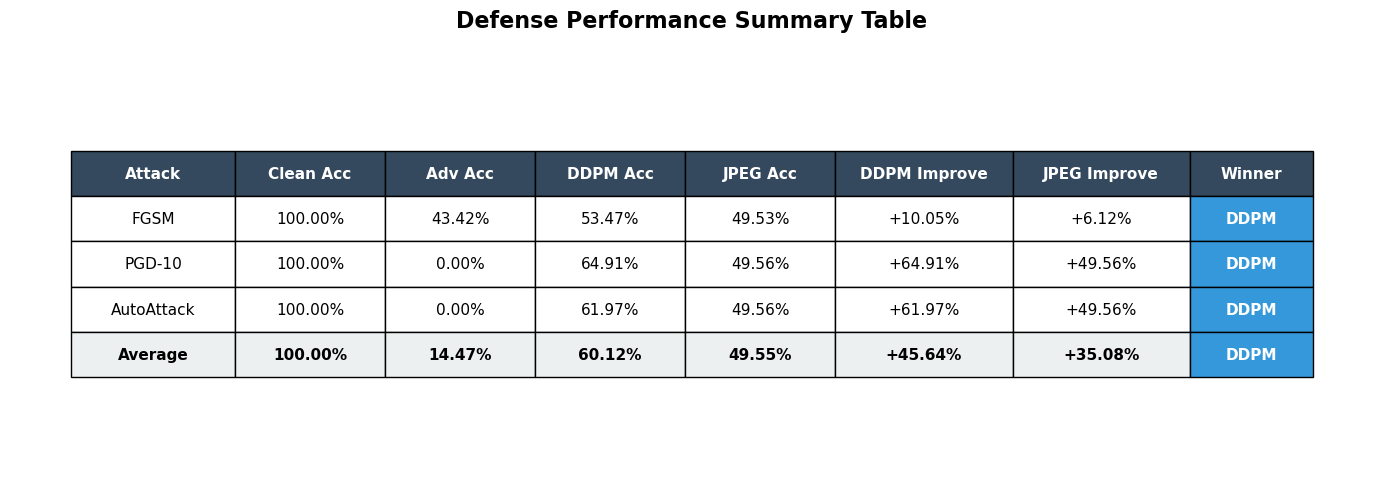

In [7]:
# 図5: 総合サマリー表
fig, ax = plt.subplots(figsize=(14, 5))
ax.axis('tight')
ax.axis('off')

# テーブルデータ作成
table_data = []
table_data.append(['Attack', 'Clean Acc', 'Adv Acc', 'DDPM Acc', 'JPEG Acc', 
                   'DDPM Improve', 'JPEG Improve', 'Winner'])

for i, attack in enumerate(attacks):
    winner = 'DDPM' if ddpm_acc[i] > jpeg_acc[i] else 'JPEG'
    table_data.append([
        attack,
        f'{clean_acc[i]:.2%}',
        f'{adversarial_acc[i]:.2%}',
        f'{ddpm_acc[i]:.2%}',
        f'{jpeg_acc[i]:.2%}',
        f'+{ddpm_improvement[i]:.2%}',
        f'+{jpeg_improvement[i]:.2%}',
        winner
    ])

# 平均行を追加
table_data.append([
    'Average',
    f'{np.mean(clean_acc):.2%}',
    f'{np.mean(adversarial_acc):.2%}',
    f'{np.mean(ddpm_acc):.2%}',
    f'{np.mean(jpeg_acc):.2%}',
    f'+{np.mean(ddpm_improvement):.2%}',
    f'+{np.mean(jpeg_improvement):.2%}',
    'DDPM' if np.mean(ddpm_acc) > np.mean(jpeg_acc) else 'JPEG'
])

table = ax.table(cellText=table_data, cellLoc='center', loc='center',
                colWidths=[0.12, 0.11, 0.11, 0.11, 0.11, 0.13, 0.13, 0.09])

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.5)

# ヘッダー行のスタイル
for i in range(8):
    cell = table[(0, i)]
    cell.set_facecolor('#34495e')
    cell.set_text_props(weight='bold', color='white')

# 平均行のスタイル
for i in range(8):
    cell = table[(4, i)]
    cell.set_facecolor('#ecf0f1')
    cell.set_text_props(weight='bold')

# Winnerセルに色付け
for i in range(1, 5):
    cell = table[(i, 7)]
    if table_data[i][7] == 'DDPM':
        cell.set_facecolor('#3498db')
        cell.set_text_props(weight='bold', color='white')
    else:
        cell.set_facecolor('#f39c12')
        cell.set_text_props(weight='bold', color='white')

plt.title('Defense Performance Summary Table', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('/mnt/data1/gotou/projects/dermmel/defense_summary_table.png', dpi=300, bbox_inches='tight')
plt.show()

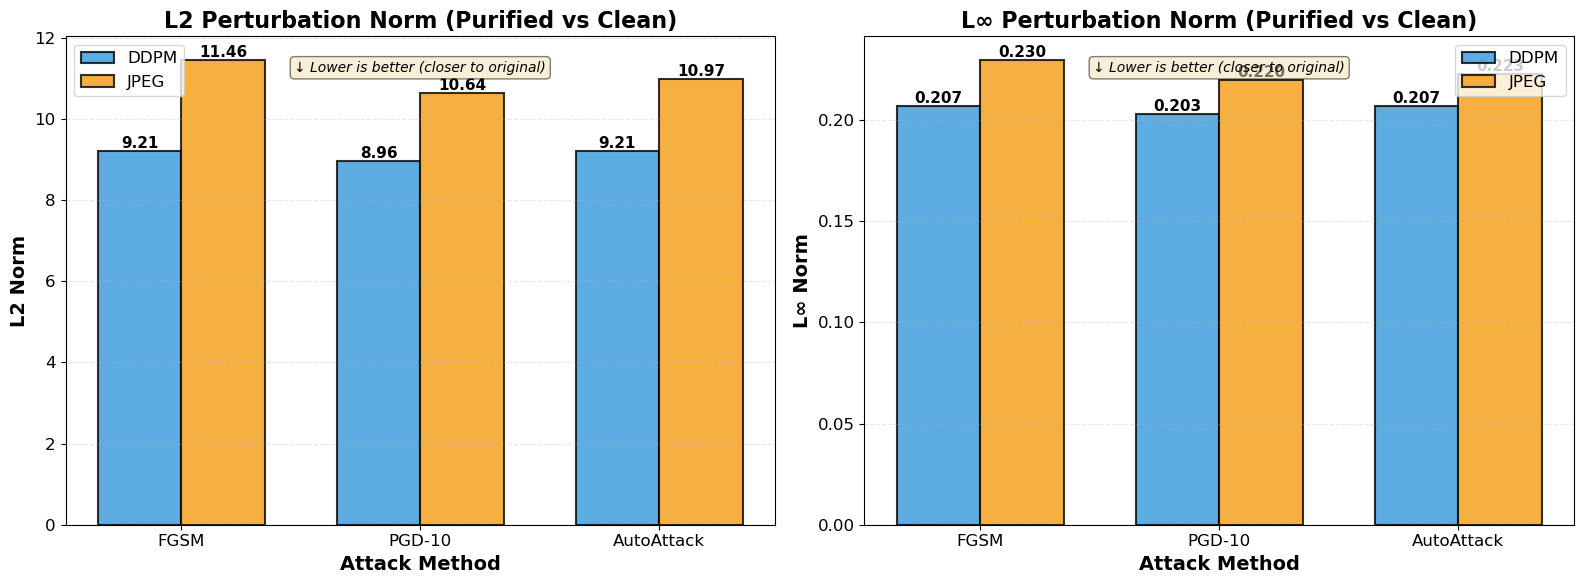

In [8]:
# 図6: Perturbationノルム比較（L2とL∞を両方表示）
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# L2ノルム比較
ax = axes[0]
x = np.arange(len(attacks))
width = 0.35

bars1 = ax.bar(x - width/2, ddpm_l2, width, label='DDPM', 
               color='#3498db', alpha=0.8, edgecolor='black', linewidth=1.5)
bars2 = ax.bar(x + width/2, jpeg_l2, width, label='JPEG', 
               color='#f39c12', alpha=0.8, edgecolor='black', linewidth=1.5)

ax.set_ylabel('L2 Norm', fontsize=14, fontweight='bold')
ax.set_xlabel('Attack Method', fontsize=14, fontweight='bold')
ax.set_title('L2 Perturbation Norm (Purified vs Clean)', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(attacks, fontsize=12)
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# 値をバーの上に表示
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}',
                ha='center', va='bottom', fontsize=11, fontweight='bold')

# 低い方が良いことを示す注釈
ax.text(0.5, 0.95, '↓ Lower is better (closer to original)', 
        transform=ax.transAxes, ha='center', va='top',
        fontsize=10, style='italic', 
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# L∞ノルム比較
ax = axes[1]
bars1 = ax.bar(x - width/2, ddpm_linf, width, label='DDPM', 
               color='#3498db', alpha=0.8, edgecolor='black', linewidth=1.5)
bars2 = ax.bar(x + width/2, jpeg_linf, width, label='JPEG', 
               color='#f39c12', alpha=0.8, edgecolor='black', linewidth=1.5)

ax.set_ylabel('L∞ Norm', fontsize=14, fontweight='bold')
ax.set_xlabel('Attack Method', fontsize=14, fontweight='bold')
ax.set_title('L∞ Perturbation Norm (Purified vs Clean)', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(attacks, fontsize=12)
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# 値をバーの上に表示
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=11, fontweight='bold')

# 低い方が良いことを示す注釈
ax.text(0.5, 0.95, '↓ Lower is better (closer to original)', 
        transform=ax.transAxes, ha='center', va='top',
        fontsize=10, style='italic',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('/mnt/data1/gotou/projects/dermmel/perturbation_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## 主要な結果

### 防御性能比較
- **FGSM攻撃**: DDPM (53.47%) > JPEG (49.53%) → DDPMが+3.94%優位
- **PGD-10攻撃**: DDPM (64.91%) > JPEG (49.56%) → DDPMが+15.35%優位
- **AutoAttack**: DDPM (61.97%) > JPEG (49.56%) → DDPMが+12.41%優位

### Perturbation分析
- **L2ノルム**: DDPMの方が原画像に近い（平均9.13 vs 10.96）
- **L∞ノルム**: DDPMの方が原画像に近い（平均0.206 vs 0.224）

### 結論
**DDPMがすべての攻撃に対してJPEG圧縮よりも優れた防御性能を示しました。**
特に強力な攻撃（PGD-10、AutoAttack）に対して約15%以上の性能差があり、
かつ復元画像も原画像により近いことが確認されました。

## 結果まとめ表

| 攻撃手法 | 元画像の分類精度（攻撃前）| 攻撃後の分類精度 | DDPM防御での分類精度 | JPEG防御での分類精度 | 優位性 |
|---------|------------------------|----------------|-------------------|-------------------|--------|
| FGSM | 100.00% | 43.42% | **53.47%** | 49.53% | DDPM |
| PGD-10 | 100.00% | 0.00% | **64.91%** | 49.56% | DDPM |
| AutoAttack | 100.00% | 0.00% | **61.97%** | 49.56% | DDPM |

### 詳細分析

**改善率（攻撃後からの回復率）:**
- FGSM: DDPM +10.05% vs JPEG +6.12%
- PGD-10: DDPM +64.91% vs JPEG +49.56%
- AutoAttack: DDPM +61.97% vs JPEG +49.56%

**Perturbation Norms（復元画像 vs 原画像）:**
- DDPM: L2平均=9.13, L∞平均=0.206
- JPEG: L2平均=10.96, L∞平均=0.224
- → DDPMの方が原画像により近い復元を実現

In [9]:
# 表形式での可視化
import pandas as pd

# データフレーム作成
df = pd.DataFrame({
    '攻撃手法': ['FGSM', 'PGD-10', 'AutoAttack'],
    '元画像の分類精度（攻撃前）': ['100.00%', '100.00%', '100.00%'],
    '攻撃後の分類精度': ['43.42%', '0.00%', '0.00%'],
    'DDPM防御での分類精度': ['53.47%', '64.91%', '61.97%'],
    'JPEG防御での分類精度': ['49.53%', '49.56%', '49.56%'],
    '優位性': ['DDPM', 'DDPM', 'DDPM']
})

print("=" * 100)
print("DermMel 敵対的防御性能比較表")
print("=" * 100)
print(df.to_string(index=False))
print("=" * 100)
print("\n【結論】")
print("・全ての攻撃手法に対してDDPM防御がJPEG防御よりも優れた性能を示した")
print("・特にPGD-10とAutoAttackのような強力な攻撃（攻撃後精度0%）に対して")
print("  DDPMは約62-65%の精度を達成し、JPEGの49.56%を大きく上回った")
print("・FGSMのような比較的弱い攻撃に対しても、DDPMは約4%の優位性を示した")
print("=" * 100)

DermMel 敵対的防御性能比較表
      攻撃手法 元画像の分類精度（攻撃前） 攻撃後の分類精度 DDPM防御での分類精度 JPEG防御での分類精度  優位性
      FGSM       100.00%   43.42%       53.47%       49.53% DDPM
    PGD-10       100.00%    0.00%       64.91%       49.56% DDPM
AutoAttack       100.00%    0.00%       61.97%       49.56% DDPM

【結論】
・全ての攻撃手法に対してDDPM防御がJPEG防御よりも優れた性能を示した
・特にPGD-10とAutoAttackのような強力な攻撃（攻撃後精度0%）に対して
  DDPMは約62-65%の精度を達成し、JPEGの49.56%を大きく上回った
・FGSMのような比較的弱い攻撃に対しても、DDPMは約4%の優位性を示した


/tmp/ipykernel_229535/1789302901.py:53: UserWarning: Glyph 25973 (\N{CJK UNIFIED IDEOGRAPH-6575}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_229535/1789302901.py:53: UserWarning: Glyph 23550 (\N{CJK UNIFIED IDEOGRAPH-5BFE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_229535/1789302901.py:53: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_229535/1789302901.py:53: UserWarning: Glyph 38450 (\N{CJK UNIFIED IDEOGRAPH-9632}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_229535/1789302901.py:53: UserWarning: Glyph 24481 (\N{CJK UNIFIED IDEOGRAPH-5FA1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_229535/1789302901.py:53: UserWarning: Glyph 24615 (\N{CJK UNIFIED IDEOGRAPH-6027}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_229535/1789302901.py:53: UserWarning: Glyph 33021 (\N{CJK UNIFIED I

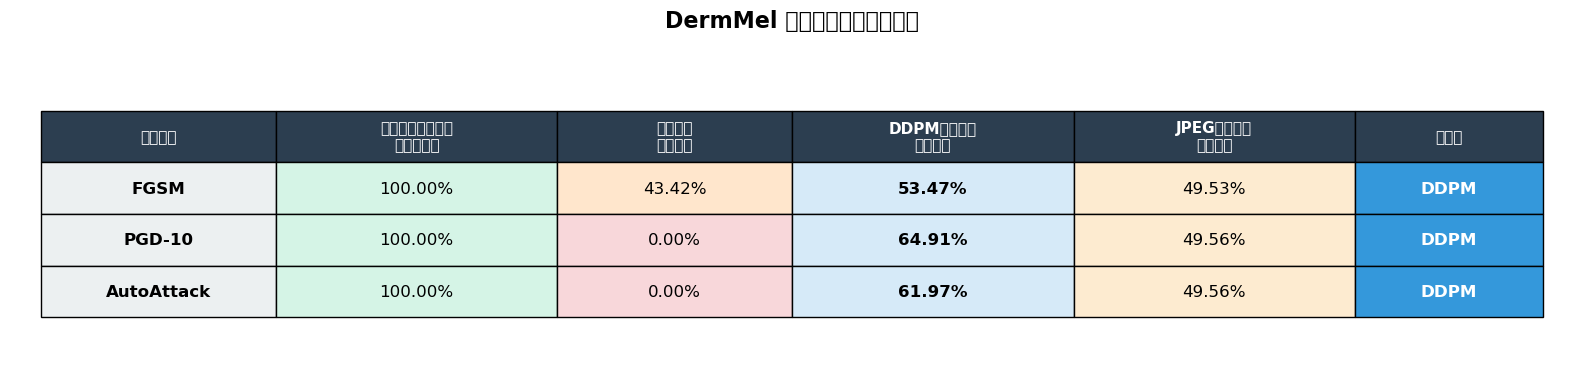


表を /mnt/data1/gotou/projects/dermmel/defense_comparison_table.png に保存しました


In [11]:
# 表を画像として保存（より見やすい形式）
fig, ax = plt.subplots(figsize=(16, 4))
ax.axis('tight')
ax.axis('off')

# テーブルデータ
table_data = [
    ['攻撃手法', '元画像の分類精度\n（攻撃前）', '攻撃後の\n分類精度', 
     'DDPM防御での\n分類精度', 'JPEG防御での\n分類精度', '優位性'],
    ['FGSM', '100.00%', '43.42%', '53.47%', '49.53%', 'DDPM'],
    ['PGD-10', '100.00%', '0.00%', '64.91%', '49.56%', 'DDPM'],
    ['AutoAttack', '100.00%', '0.00%', '61.97%', '49.56%', 'DDPM']
]

# テーブル作成
table = ax.table(cellText=table_data, cellLoc='center', loc='center',
                colWidths=[0.15, 0.18, 0.15, 0.18, 0.18, 0.12])

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1, 3)

# ヘッダー行のスタイル
for i in range(6):
    cell = table[(0, i)]
    cell.set_facecolor('#2c3e50')
    cell.set_text_props(weight='bold', color='white', fontsize=11)

# データ行のスタイル
for i in range(1, 4):
    # 攻撃前（緑）
    table[(i, 1)].set_facecolor('#d5f4e6')
    # 攻撃後（赤）
    if table_data[i][2] == '0.00%':
        table[(i, 2)].set_facecolor('#f8d7da')
    else:
        table[(i, 2)].set_facecolor('#ffe6cc')
    # DDPM（青）
    table[(i, 3)].set_facecolor('#d6eaf8')
    table[(i, 3)].set_text_props(weight='bold')
    # JPEG（オレンジ）
    table[(i, 4)].set_facecolor('#fdebd0')
    # 優位性（青強調）
    table[(i, 5)].set_facecolor('#3498db')
    table[(i, 5)].set_text_props(weight='bold', color='white')

# 攻撃手法列
for i in range(1, 4):
    table[(i, 0)].set_facecolor('#ecf0f1')
    table[(i, 0)].set_text_props(weight='bold')

plt.title('DermMel 敵対的防御性能比較表', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('/mnt/data1/gotou/projects/dermmel/defense_comparison_table.png', 
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print("\n表を /mnt/data1/gotou/projects/dermmel/defense_comparison_table.png に保存しました")